In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_loans.csv')

print(" Cleaned data loaded!")
print("Shape:", df.shape)
print("\nTarget distribution:")
print(df['default'].value_counts())
print("\nDefault Rate:", round(df['default'].mean()*100, 2), "%")

 Cleaned data loaded!
Shape: (1344936, 39)

Target distribution:
default
0    1076448
1     268488
Name: count, dtype: int64

Default Rate: 19.96 %


In [2]:
X = df.drop('default', axis=1)
y = df['default']

print(" Features (X) shape:", X.shape)
print(" Target  (y) shape:", y.shape)
print("\nFeature columns:")
for col in X.columns:
    print(" -", col)

 Features (X) shape: (1344936, 38)
 Target  (y) shape: (1344936,)

Feature columns:
 - loan_amnt
 - int_rate
 - installment
 - emp_length
 - annual_inc
 - dti
 - fico_range_low
 - open_acc
 - pub_rec
 - revol_bal
 - revol_util
 - total_acc
 - loan_to_income
 - monthly_burden
 - home_ownership_MORTGAGE
 - home_ownership_NONE
 - home_ownership_OTHER
 - home_ownership_OWN
 - home_ownership_RENT
 - purpose_credit_card
 - purpose_debt_consolidation
 - purpose_educational
 - purpose_home_improvement
 - purpose_house
 - purpose_major_purchase
 - purpose_medical
 - purpose_moving
 - purpose_other
 - purpose_renewable_energy
 - purpose_small_business
 - purpose_vacation
 - purpose_wedding
 - grade_B
 - grade_C
 - grade_D
 - grade_E
 - grade_F
 - grade_G


In [3]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y.value_counts())

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).value_counts())
print("\n Class imbalance fixed!")

Before SMOTE:
default
0    1076448
1     268488
Name: count, dtype: int64

After SMOTE:
default
0    1076448
1    1076448
Name: count, dtype: int64

 Class imbalance fixed!


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Train/Test Split done!")
print("Training set size :", X_train_scaled.shape)
print("Testing  set size :", X_test_scaled.shape)

 Train/Test Split done!
Training set size : (1722316, 38)
Testing  set size : (430580, 38)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

print("Training Logistic Regression... ⏳")

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("\n Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_lr), 4))

Training Logistic Regression... ⏳

 Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.78      0.97      0.87    214821
           1       0.96      0.73      0.83    215759

    accuracy                           0.85    430580
   macro avg       0.87      0.85      0.85    430580
weighted avg       0.87      0.85      0.85    430580

ROC-AUC Score: 0.9106


In [6]:
from xgboost import XGBClassifier

print("Training XGBoost... ⏳ (may take 3-5 mins)")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:,1]

print("\n XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_xgb), 4))

Training XGBoost... ⏳ (may take 3-5 mins)

 XGBoost Results:
              precision    recall  f1-score   support

           0       0.80      0.98      0.88    214821
           1       0.98      0.75      0.85    215759

    accuracy                           0.87    430580
   macro avg       0.89      0.87      0.86    430580
weighted avg       0.89      0.87      0.86    430580

ROC-AUC Score: 0.9228


 Model Comparison:
                 Model  ROC-AUC
0  Logistic Regression   0.9106
1              XGBoost   0.9228


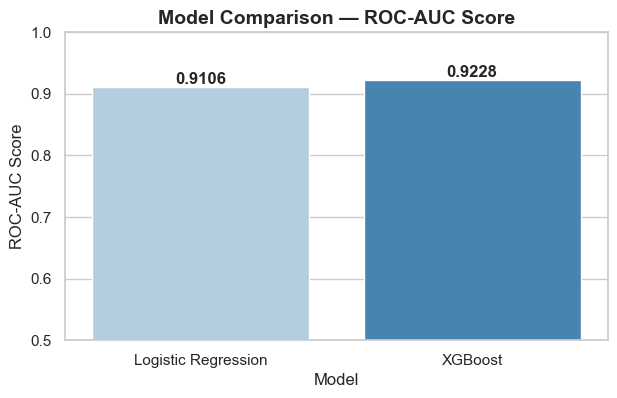

 Plot saved!


In [7]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_lr), 4),
        round(roc_auc_score(y_test, y_prob_xgb), 4)
    ]
})

print(" Model Comparison:")
print(results)

# Bar chart
plt.figure(figsize=(7,4))
sns.barplot(data=results, x='Model', y='ROC-AUC',
            hue='Model', palette='Blues', legend=False)
plt.ylim(0.5, 1.0)
plt.title('Model Comparison — ROC-AUC Score', fontsize=14, fontweight='bold')
plt.ylabel('ROC-AUC Score')
for i, v in enumerate(results['ROC-AUC']):
    plt.text(i, v + 0.005, str(v), ha='center', fontweight='bold')
plt.savefig('../outputs/05_model_comparison.png', bbox_inches='tight')
plt.show()
print(" Plot saved!")

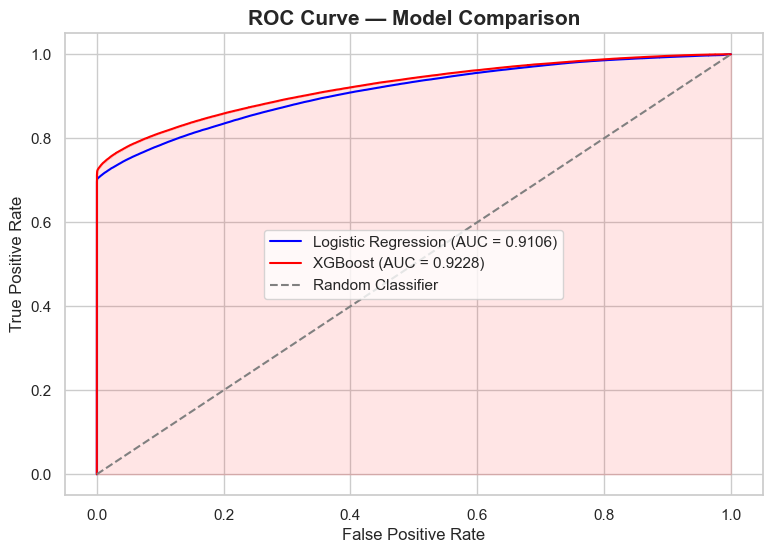

 ROC Curve saved!


In [9]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(9,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = 0.9106)', color='blue')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = 0.9228)', color='red')
plt.plot([0,1],[0,1],'--', color='gray', label='Random Classifier')
plt.fill_between(fpr_xgb, tpr_xgb, alpha=0.1, color='red')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Model Comparison', fontsize=15, fontweight='bold')
plt.legend(fontsize=11)
plt.savefig('../outputs/06_roc_curve.png', bbox_inches='tight')
plt.show()
print(" ROC Curve saved!")

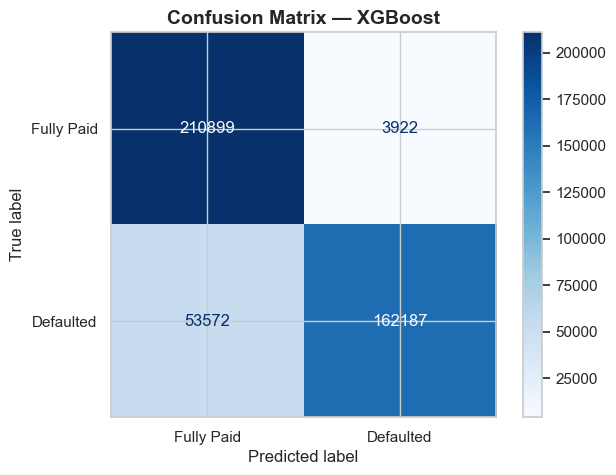

Business Interpretation:
  Correctly predicted Fully Paid  : 210,899
  Correctly predicted Defaulted   : 162,187
  Missed Defaults (False Negative) : 53,572  ← COSTLY for bank!
  False Alarms   (False Positive)  : 3,922


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7,5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fully Paid', 'Defaulted']
)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix — XGBoost', fontsize=14, fontweight='bold')
plt.savefig('../outputs/07_confusion_matrix.png', bbox_inches='tight')
plt.show()

# Business interpretation
tn, fp, fn, tp = cm.ravel()
print("Business Interpretation:")
print(f"  Correctly predicted Fully Paid  : {tn:,}")
print(f"  Correctly predicted Defaulted   : {tp:,}")
print(f"  Missed Defaults (False Negative) : {fn:,}  ← COSTLY for bank!")
print(f"  False Alarms   (False Positive)  : {fp:,}")

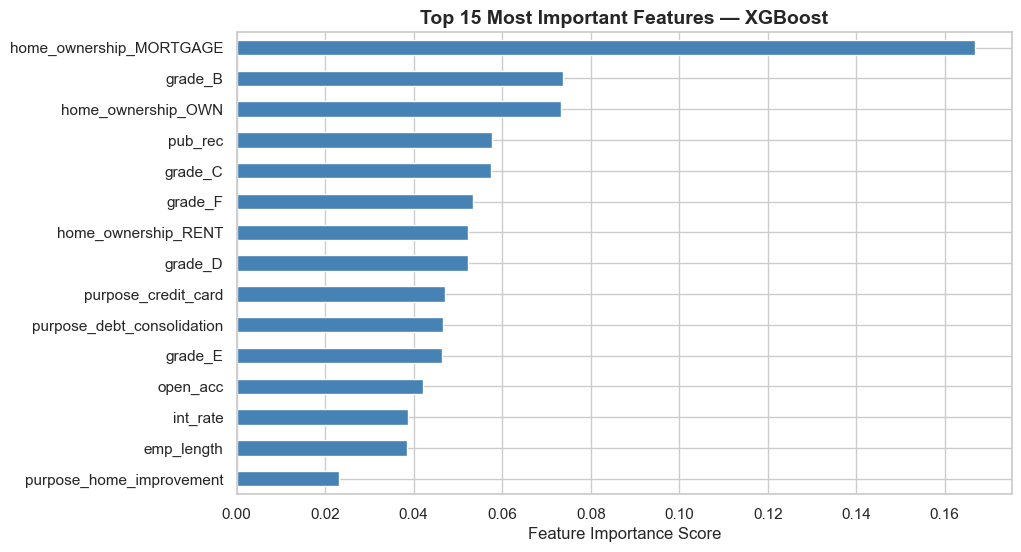

Top 5 most important features:
  1. home_ownership_MORTGAGE → 0.1668
  2. grade_B → 0.0738
  3. home_ownership_OWN → 0.0734
  4. pub_rec → 0.0577
  5. grade_C → 0.0574


In [11]:
feature_names = X.columns.tolist()

feat_imp = pd.Series(
    xgb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)[:15]

plt.figure(figsize=(10,6))
feat_imp.sort_values().plot(
    kind='barh',
    color='steelblue',
    edgecolor='white'
)
plt.title('Top 15 Most Important Features — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.savefig('../outputs/08_feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
for i, (feat, score) in enumerate(feat_imp.head().items(), 1):
    print(f"  {i}. {feat} → {score:.4f}")

In [12]:
import pickle

# Save XGBoost model
with open('../outputs/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Save scaler
with open('../outputs/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('../outputs/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print(" Model saved!")
print(" Scaler saved!")
print(" Feature names saved!")
print("\nAll files in outputs folder:")
import os
for f in os.listdir('../outputs'):
    print(" -", f)

 Model saved!
 Scaler saved!
 Feature names saved!

All files in outputs folder:
 - 01_defaults_distribution.png
 - 02_default_by_grade.png
 - 03_default_by_purpose.png
 - 04_credit_score_vs_default.png
 - 05_model_comparison.png
 - 06_roc_curve.png
 - 07_confusion_matrix.png
 - 08_feature_importance.png
 - feature_names.pkl
 - scaler.pkl
 - xgb_model.pkl


In [13]:
# Take a sample for Power BI dashboard
df_sample = df.sample(n=50000, random_state=42).copy()

X_sample = df_sample.drop('default', axis=1)
X_sample_scaled = scaler.transform(X_sample)

df_sample['predicted_default'] = xgb.predict(X_sample_scaled)
df_sample['default_probability'] = xgb.predict_proba(X_sample_scaled)[:,1].round(4)

df_sample.to_csv('../dashboard/loan_predictions.csv', index=False)

print(" Dashboard data exported!")
print("Shape:", df_sample.shape)

 Dashboard data exported!
Shape: (50000, 41)


In [3]:
import pandas as pd
import os

# Load original raw data
print("Loading... please wait ⏳")
df_raw = pd.read_csv('../data/raw/accepted_2007_to_2018Q4.csv', low_memory=False)
df_raw = df_raw[df_raw['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# Create target column
df_raw['default'] = (df_raw['loan_status'] == 'Charged Off').astype(int)

# Select original readable columns
dashboard_cols = [
    'loan_amnt', 'int_rate', 'annual_inc',
    'grade', 'purpose', 'home_ownership',
    'dti', 'emp_length', 'default'
]

df_raw = df_raw[dashboard_cols].dropna()

# Take 50000 sample
df_final = df_raw.sample(n=50000, random_state=42).copy()

# Save
os.makedirs('../dashboard', exist_ok=True)
df_final.to_csv('../dashboard/loan_dashboard.csv', index=False)

print(" Dashboard file created!")
print("Shape:", df_final.shape)
print("Columns:", df_final.columns.tolist())
print("\nGrade values:", sorted(df_final['grade'].unique()))

Loading... please wait ⏳


C:\Users\pench\AppData\Local\Temp\ipykernel_27312\506007655.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_raw['default'] = (df_raw['loan_status'] == 'Charged Off').astype(int)


 Dashboard file created!
Shape: (50000, 9)
Columns: ['loan_amnt', 'int_rate', 'annual_inc', 'grade', 'purpose', 'home_ownership', 'dti', 'emp_length', 'default']

Grade values: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
